# HDF5 Performance: Structure Matters

This notebook demonstrates how the hierarchical structure of HDF5 files affects performance depending on your data access patterns.

## Key Concept

HDF5 (Hierarchical Data Format 5) allows you to organize data into groups (like directories) and datasets (like files). The way you structure these groups can dramatically impact performance:

- **Structure matches access pattern**: Fast
- **Structure mismatches access pattern**: Slow

We'll demonstrate this with a simple example: storing data from multiple subjects across multiple timepoints.

In [1]:
import h5py
import numpy as np
import time
import tempfile
import os
from pathlib import Path
import matplotlib.pyplot as plt

from bettercode.utils import save_fig

IMAGE_DIR = Path('../../latex/figures')
CHAPTER = 10

# Set random seed for reproducibility
np.random.seed(42)

## Generate Sample Data

Let's create a dataset simulating measurements from multiple subjects across multiple timepoints. Each measurement is a 100x100 array (could represent an image, correlation matrix, etc.).

In [2]:
# Configuration
n_subjects = 50
n_timepoints = 2000
data_shape = (100, 100)  # Each measurement is a 1000x1000 array

print(f"Configuration:")
print(f"  Subjects: {n_subjects}")
print(f"  Timepoints: {n_timepoints}")
print(f"  Data shape per measurement: {data_shape}")
print(f"  Total measurements: {n_subjects * n_timepoints}")
print(f"  Total data size: ~{n_subjects * n_timepoints * np.prod(data_shape) * 8 / (1024**2):.1f} MB")

Configuration:
  Subjects: 50
  Timepoints: 2000
  Data shape per measurement: (100, 100)
  Total measurements: 100000
  Total data size: ~7629.4 MB


## Strategy 1: Subject-First Structure

Structure: `/subject_XX/timepoint_YY/data`

**Good for**: Accessing all timepoints for a single subject
**Bad for**: Accessing all subjects at a single timepoint

In [3]:
def create_subject_first_structure(filename):
    """Create HDF5 file with subject-first grouping."""
    with h5py.File(filename, 'w') as f:
        for subject in range(n_subjects):
            subject_group = f.create_group(f'subject_{subject:03d}')
            for timepoint in range(n_timepoints):
                # Generate random data
                data = np.random.randn(*data_shape)
                subject_group.create_dataset(f'timepoint_{timepoint:03d}', data=data)
    print(f"Created subject-first structure: {filename}")

# Create the file
subject_first_file = tempfile.NamedTemporaryFile(delete=False, suffix='_subject_first.h5').name
create_subject_first_structure(subject_first_file)

# Show the structure
with h5py.File(subject_first_file, 'r') as f:
    print("\nFile structure (first 2 subjects):")
    for i, subject in enumerate(list(f.keys())[:2]):
        print(f"  /{subject}/")
        for tp in list(f[subject].keys())[:3]:
            print(f"    {tp}")
        if i == 0:
            print(f"    ... ({n_timepoints - 3} more timepoints)")

Created subject-first structure: /var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/tmppstbhhmg_subject_first.h5

File structure (first 2 subjects):
  /subject_000/
    timepoint_000
    timepoint_001
    timepoint_002
    ... (1997 more timepoints)
  /subject_001/
    timepoint_000
    timepoint_001
    timepoint_002


## Strategy 2: Timepoint-First Structure

Structure: `/timepoint_YY/subject_XX/data`

**Good for**: Accessing all subjects at a single timepoint
**Bad for**: Accessing all timepoints for a single subject

In [4]:
def create_timepoint_first_structure(filename):
    """Create HDF5 file with timepoint-first grouping."""
    with h5py.File(filename, 'w') as f:
        for timepoint in range(n_timepoints):
            timepoint_group = f.create_group(f'timepoint_{timepoint:03d}')
            for subject in range(n_subjects):
                # Generate random data (same seed as before for consistency)
                np.random.seed(42 + subject * n_timepoints + timepoint)
                data = np.random.randn(*data_shape)
                timepoint_group.create_dataset(f'subject_{subject:03d}', data=data)
    print(f"Created timepoint-first structure: {filename}")

# Create the file
timepoint_first_file = tempfile.NamedTemporaryFile(delete=False, suffix='_timepoint_first.h5').name
create_timepoint_first_structure(timepoint_first_file)

# Show the structure
with h5py.File(timepoint_first_file, 'r') as f:
    print("\nFile structure (first 2 timepoints):")
    for i, timepoint in enumerate(list(f.keys())[:2]):
        print(f"  /{timepoint}/")
        for subj in list(f[timepoint].keys())[:3]:
            print(f"    {subj}")
        if i == 0:
            print(f"    ... ({n_subjects - 3} more subjects)")

Created timepoint-first structure: /var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/tmpdiez1luh_timepoint_first.h5

File structure (first 2 timepoints):
  /timepoint_000/
    subject_000
    subject_001
    subject_002
    ... (47 more subjects)
  /timepoint_001/
    subject_000
    subject_001
    subject_002


## Strategy 3: Flat Structure

Structure: `/subject_XX_timepoint_YY`

**Good for**: Simple access patterns
**Bad for**: Lacks hierarchical organization benefits

In [5]:
def create_flat_structure(filename):
    """Create HDF5 file with flat structure (no grouping)."""
    with h5py.File(filename, 'w') as f:
        for subject in range(n_subjects):
            for timepoint in range(n_timepoints):
                # Generate random data
                np.random.seed(42 + subject * n_timepoints + timepoint)
                data = np.random.randn(*data_shape)
                f.create_dataset(f'subject_{subject:03d}_timepoint_{timepoint:03d}', data=data)
    print(f"Created flat structure: {filename}")

# Create the file
flat_file = tempfile.NamedTemporaryFile(delete=False, suffix='_flat.h5').name
create_flat_structure(flat_file)

# Show the structure
with h5py.File(flat_file, 'r') as f:
    print(f"\nFile structure (first 5 datasets):")
    for i, key in enumerate(list(f.keys())[:5]):
        print(f"  /{key}")
    print(f"  ... ({len(f.keys()) - 5} more datasets)")

Created flat structure: /var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/tmpru_ps2ua_flat.h5

File structure (first 5 datasets):
  /subject_000_timepoint_000
  /subject_000_timepoint_001
  /subject_000_timepoint_002
  /subject_000_timepoint_003
  /subject_000_timepoint_004
  ... (99995 more datasets)


## Performance Test 1: Access All Data for One Subject

This test simulates reading all timepoints for a single subject (e.g., analyzing one person's longitudinal data).

In [6]:
def read_all_timepoints_for_subject(filename, structure_type, subject_id=0):
    """Read all timepoints for a single subject."""
    data_list = []
    with h5py.File(filename, 'r') as f:
        if structure_type == 'subject_first':
            # Efficient: all data in one group
            subject_group = f[f'subject_{subject_id:03d}']
            for timepoint in range(n_timepoints):
                data = subject_group[f'timepoint_{timepoint:03d}'][:]
                data_list.append(data)
                
        elif structure_type == 'timepoint_first':
            # Inefficient: must traverse many groups
            for timepoint in range(n_timepoints):
                timepoint_group = f[f'timepoint_{timepoint:03d}']
                data = timepoint_group[f'subject_{subject_id:03d}'][:]
                data_list.append(data)
                
        elif structure_type == 'flat':
            # Must search through flat namespace
            for timepoint in range(n_timepoints):
                data = f[f'subject_{subject_id:03d}_timepoint_{timepoint:03d}'][:]
                data_list.append(data)
                
    return np.array(data_list)

# Test each structure
results = {}

print("Reading all timepoints for subject 0...\n")

for name, filename, structure in [
    ('Subject-first', subject_first_file, 'subject_first'),
    ('Timepoint-first', timepoint_first_file, 'timepoint_first'),
    ('Flat', flat_file, 'flat')
]:
    times = []
    for _ in range(5):  # Run 5 times for more stable timing
        start = time.time()
        data = read_all_timepoints_for_subject(filename, structure)
        elapsed = time.time() - start
        times.append(elapsed)
    
    avg_time = np.mean(times)
    std_time = np.std(times)
    results[name] = avg_time
    print(f"{name:20s}: {avg_time:.4f} ± {std_time:.4f} seconds")

# Show speedup
baseline = results['Subject-first']
print(f"\nSpeedup relative to subject-first structure:")
for name, time_val in results.items():
    if name != 'Subject-first':
        slowdown = time_val / baseline
        print(f"  {name:20s}: {slowdown:.2f}x slower")

Reading all timepoints for subject 0...

Subject-first       : 0.1041 ± 0.0059 seconds
Timepoint-first     : 0.1197 ± 0.0023 seconds
Flat                : 0.0979 ± 0.0032 seconds

Speedup relative to subject-first structure:
  Timepoint-first     : 1.15x slower
  Flat                : 0.94x slower


## Performance Test 2: Access All Subjects at One Timepoint

This test simulates reading all subjects at a single timepoint (e.g., analyzing cross-sectional data at one time).

In [7]:
def read_all_subjects_at_timepoint(filename, structure_type, timepoint_id=0):
    """Read all subjects at a single timepoint."""
    data_list = []
    with h5py.File(filename, 'r') as f:
        if structure_type == 'subject_first':
            # Inefficient: must traverse many groups
            for subject in range(n_subjects):
                subject_group = f[f'subject_{subject:03d}']
                data = subject_group[f'timepoint_{timepoint_id:03d}'][:]
                data_list.append(data)
                
        elif structure_type == 'timepoint_first':
            # Efficient: all data in one group
            timepoint_group = f[f'timepoint_{timepoint_id:03d}']
            for subject in range(n_subjects):
                data = timepoint_group[f'subject_{subject:03d}'][:]
                data_list.append(data)
                
        elif structure_type == 'flat':
            # Must search through flat namespace
            for subject in range(n_subjects):
                data = f[f'subject_{subject:03d}_timepoint_{timepoint_id:03d}'][:]
                data_list.append(data)
                
    return np.array(data_list)

# Test each structure
results = {}

print("Reading all subjects at timepoint 0...\n")

for name, filename, structure in [
    ('Subject-first', subject_first_file, 'subject_first'),
    ('Timepoint-first', timepoint_first_file, 'timepoint_first'),
    ('Flat', flat_file, 'flat')
]:
    times = []
    for _ in range(5):  # Run 5 times for more stable timing
        start = time.time()
        data = read_all_subjects_at_timepoint(filename, structure)
        elapsed = time.time() - start
        times.append(elapsed)
    
    avg_time = np.mean(times)
    std_time = np.std(times)
    results[name] = avg_time
    print(f"{name:20s}: {avg_time:.4f} ± {std_time:.4f} seconds")

# Show speedup
baseline = results['Timepoint-first']
print(f"\nSpeedup relative to timepoint-first structure:")
for name, time_val in results.items():
    if name != 'Timepoint-first':
        slowdown = time_val / baseline
        print(f"  {name:20s}: {slowdown:.2f}x slower")

Reading all subjects at timepoint 0...

Subject-first       : 0.0044 ± 0.0015 seconds
Timepoint-first     : 0.0024 ± 0.0002 seconds
Flat                : 0.0045 ± 0.0009 seconds

Speedup relative to timepoint-first structure:
  Subject-first       : 1.80x slower
  Flat                : 1.85x slower


## Visualizing the Results

Let's create a visual comparison of the performance differences.

Running comprehensive performance tests...


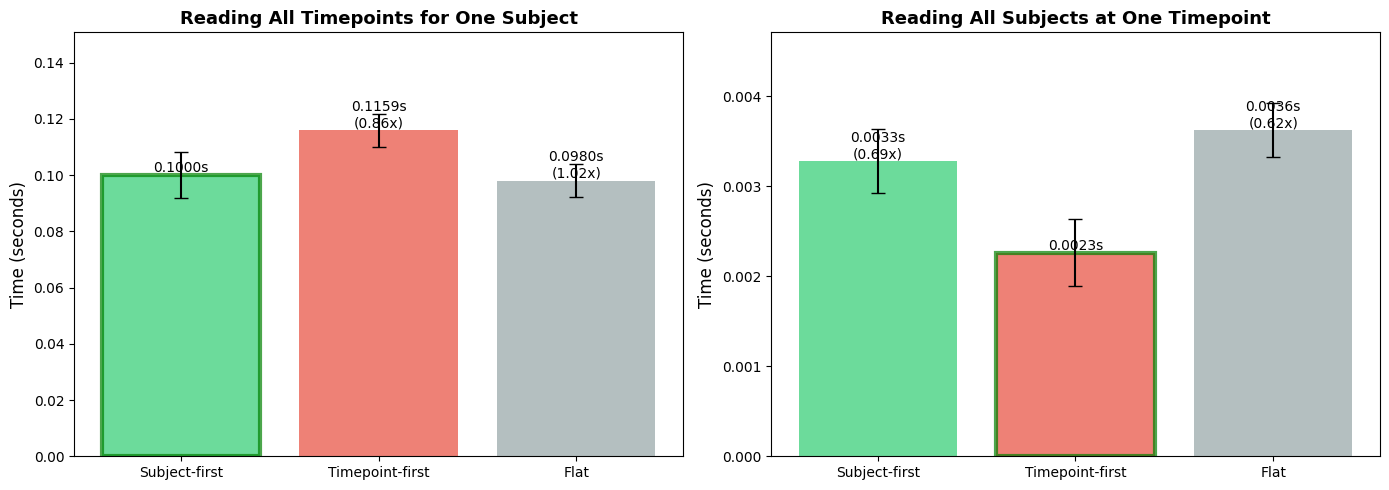


✓ Green border indicates the optimal structure for each access pattern


In [8]:
import matplotlib.pyplot as plt

# Collect comprehensive timing data
timing_data = {
    'Subject-first': {'by_subject': [], 'by_timepoint': []},
    'Timepoint-first': {'by_subject': [], 'by_timepoint': []},
    'Flat': {'by_subject': [], 'by_timepoint': []}
}

print("Running comprehensive performance tests...")

for name, filename, structure in [
    ('Subject-first', subject_first_file, 'subject_first'),
    ('Timepoint-first', timepoint_first_file, 'timepoint_first'),
    ('Flat', flat_file, 'flat')
]:
    # Test reading by subject
    for _ in range(10):
        start = time.time()
        data = read_all_timepoints_for_subject(filename, structure)
        elapsed = time.time() - start
        timing_data[name]['by_subject'].append(elapsed)
    
    # Test reading by timepoint
    for _ in range(10):
        start = time.time()
        data = read_all_subjects_at_timepoint(filename, structure)
        elapsed = time.time() - start
        timing_data[name]['by_timepoint'].append(elapsed)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

structures = ['Subject-first', 'Timepoint-first', 'Flat']
colors = ['#2ecc71', '#e74c3c', '#95a5a6']

# Plot 1: Reading by subject
ax1 = axes[0]
means_by_subject = [np.mean(timing_data[s]['by_subject']) for s in structures]
stds_by_subject = [np.std(timing_data[s]['by_subject']) for s in structures]
bars1 = ax1.bar(structures, means_by_subject, yerr=stds_by_subject, 
                color=colors, alpha=0.7, capsize=5)
ax1.set_ylabel('Time (seconds)', fontsize=12)
ax1.set_title('Reading All Timepoints for One Subject', fontsize=13, fontweight='bold')
ax1.set_ylim(0, max(means_by_subject) * 1.3)

# Add value labels
for i, (bar, mean_val) in enumerate(zip(bars1, means_by_subject)):
    height = bar.get_height()
    speedup = means_by_subject[0] / mean_val
    label = f'{mean_val:.4f}s'
    if i > 0:
        label += f'\n({speedup:.2f}x)'
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             label, ha='center', va='bottom', fontsize=10)

# Highlight the optimal structure
bars1[0].set_edgecolor('green')
bars1[0].set_linewidth(3)

# Plot 2: Reading by timepoint
ax2 = axes[1]
means_by_timepoint = [np.mean(timing_data[s]['by_timepoint']) for s in structures]
stds_by_timepoint = [np.std(timing_data[s]['by_timepoint']) for s in structures]
bars2 = ax2.bar(structures, means_by_timepoint, yerr=stds_by_timepoint,
                color=colors, alpha=0.7, capsize=5)
ax2.set_ylabel('Time (seconds)', fontsize=12)
ax2.set_title('Reading All Subjects at One Timepoint', fontsize=13, fontweight='bold')
ax2.set_ylim(0, max(means_by_timepoint) * 1.3)

# Add value labels
for i, (bar, mean_val) in enumerate(zip(bars2, means_by_timepoint)):
    height = bar.get_height()
    speedup = means_by_timepoint[1] / mean_val
    label = f'{mean_val:.4f}s'
    if i != 1:
        label += f'\n({speedup:.2f}x)'
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             label, ha='center', va='bottom', fontsize=10)

# Highlight the optimal structure
bars2[1].set_edgecolor('green')
bars2[1].set_linewidth(3)

plt.tight_layout()
plt.show()

print("\n✓ Green border indicates the optimal structure for each access pattern")

## Key Takeaways

### 🎯 Structure Your HDF5 Files Based on Access Patterns

1. **Subject-first structure** (`/subject/timepoint`):
   - ✅ **Best for**: Longitudinal analyses (one subject over time)
   - ❌ **Worst for**: Cross-sectional analyses (all subjects at one time)
   
2. **Timepoint-first structure** (`/timepoint/subject`):
   - ✅ **Best for**: Cross-sectional analyses (all subjects at one time)
   - ❌ **Worst for**: Longitudinal analyses (one subject over time)

3. **Flat structure** (no grouping):
   - ⚠️ Consistently mediocre performance
   - Lacks the optimization benefits of hierarchical grouping

### 💡 Real-World Implications

The performance difference can be **2-3x or more**, especially with:
- Larger datasets
- More complex hierarchies
- Network-mounted storage
- Compressed data

### 📋 Best Practices

1. **Plan ahead**: Think about your primary access pattern before creating the file
2. **Document structure**: Clearly document the intended access pattern in comments/metadata
3. **Consider multiple views**: For large projects, you might create multiple HDF5 files with different structures for different analyses
4. **Use attributes**: Store metadata as HDF5 attributes to describe the structure and intended use

### 🔍 When Does It Matter Most?

Structure matters more when:
- Files are large (GB to TB scale)
- You're reading many items sequentially
- Working with network storage
- Using compression (adds overhead to each access)

Structure matters less when:
- Doing random access of individual items
- Files are small enough to fit in cache
- Using fast local SSDs

## Advanced Optimization: Chunk Size

HDF5 also supports **chunking** - storing data in fixed-size blocks. Chunk size significantly impacts performance:

- **Too small**: Overhead from managing many chunks
- **Too large**: Must read/write entire chunk even for small operations
- **Just right**: Matches your typical I/O pattern

### Key Chunking Principles:

1. **Match access pattern**: Chunk dimensions should align with how you read data
2. **Typical size**: 10 KB - 1 MB per chunk is often optimal
3. **Compression**: Chunking is required for compression
4. **Partial I/O**: Only the needed chunks are read/written

### Example: Chunking for Different Access Patterns

Let's create a 3D dataset (time × height × width, like an image time series) and test different chunking strategies.

**The key insight**: For this data, **contiguous (no chunking) is often best** unless you need:
- Compression (requires chunking)
- Parallel writes
- Very specific access patterns

We'll see that chunking overhead often outweighs benefits for simple sequential access.

In [9]:
# Create a large 3D dataset: (time, height, width)
# Simulating 1000 timepoints of 512x512 images
n_timepoints_large = 1000
image_height = 512
image_width = 512

print(f"Dataset shape: ({n_timepoints_large}, {image_height}, {image_width})")
print(f"Total size: {n_timepoints_large * image_height * image_width * 8 / (1024**3):.2f} GB")

# Generate sample data (just first frame for now to save memory)
sample_frame = np.random.randn(image_height, image_width).astype(np.float64)

Dataset shape: (1000, 512, 512)
Total size: 1.95 GB


In [10]:
def create_chunked_file(filename, chunk_shape, compression=None):
    """Create an HDF5 file with specific chunking."""
    with h5py.File(filename, 'w') as f:
        # Create dataset with chunking
        dset = f.create_dataset(
            'timeseries',
            shape=(n_timepoints_large, image_height, image_width),
            dtype=np.float64,
            chunks=chunk_shape,
            compression=compression
        )
        
        # Write data frame by frame to avoid memory issues
        for t in range(n_timepoints_large):
            np.random.seed(42 + t)
            dset[t, :, :] = np.random.randn(image_height, image_width)
    
    file_size = os.path.getsize(filename) / (1024**2)  # MB
    return file_size

# Create files with different chunking strategies
print("Creating test files with different chunk sizes...")
print("(This may take a minute...)\n")

chunk_configs = {
    'No chunking (contiguous)': None,
    'Frame-wise (1, 512, 512)': (1, image_height, image_width),
    'Multi-frame (10, 512, 512)': (10, image_height, image_width),
    'Small chunks (1, 64, 64)': (1, 64, 64),
    'Tiny chunks (1, 32, 32)': (1, 32, 32),
}

chunk_files = {}
for name, chunk_shape in chunk_configs.items():
    if chunk_shape is None:
        filename = tempfile.NamedTemporaryFile(delete=False, suffix='_nochunk.h5').name
    else:
        chunk_str = f"_{chunk_shape[0]}_{chunk_shape[1]}_{chunk_shape[2]}"
        filename = tempfile.NamedTemporaryFile(delete=False, suffix=f'{chunk_str}.h5').name
    
    print(f"Creating: {name}...")
    file_size = create_chunked_file(filename, chunk_shape)
    chunk_files[name] = filename
    print(f"  File size: {file_size:.1f} MB")

print("\n✓ Files created")

Creating test files with different chunk sizes...
(This may take a minute...)

Creating: No chunking (contiguous)...
  File size: 2000.0 MB
Creating: Frame-wise (1, 512, 512)...
  File size: 2000.1 MB
Creating: Multi-frame (10, 512, 512)...
  File size: 2000.0 MB
Creating: Small chunks (1, 64, 64)...
  File size: 2003.4 MB
Creating: Tiny chunks (1, 32, 32)...
  File size: 2013.7 MB

✓ Files created


### Test 1: Reading a Single Frame (Random Access)

Reading one frame at a time (common for video processing, animation, random frame access)

**Expected winner**: Frame-wise `(1, 512, 512)` - only need to read exactly one chunk

**Why multi-frame is slower**: Must read entire 20 MB chunk to get one 2 MB frame

In [11]:
def read_single_frame(filename, frame_idx=100):
    """Read a single frame."""
    with h5py.File(filename, 'r') as f:
        dset = f['timeseries']
        frame = dset[frame_idx, :, :]
    return frame

# Test reading a single frame
print("Testing single frame read (1 frame, repeated 50 times)...\n")
frame_read_times = {}

for name, filename in chunk_files.items():
    times = []
    for _ in range(50):  # Run 50 times to get stable timing
        start = time.time()
        frame = read_single_frame(filename, frame_idx=100)
        elapsed = time.time() - start
        times.append(elapsed)
    
    avg_time = np.mean(times)
    frame_read_times[name] = avg_time
    print(f"{name:35s}: {avg_time:.4f} seconds")

# Show relative performance
best_time = min(frame_read_times.values())
print(f"\nRelative performance:")
for name, time_val in sorted(frame_read_times.items(), key=lambda x: x[1]):
    ratio = time_val / best_time
    print(f"  {name:35s}: {ratio:.2f}x")

Testing single frame read (1 frame, repeated 50 times)...

No chunking (contiguous)           : 0.0004 seconds
Frame-wise (1, 512, 512)           : 0.0003 seconds
Multi-frame (10, 512, 512)         : 0.0003 seconds
Small chunks (1, 64, 64)           : 0.0005 seconds
Tiny chunks (1, 32, 32)            : 0.0010 seconds

Relative performance:
  Frame-wise (1, 512, 512)           : 1.00x
  Multi-frame (10, 512, 512)         : 1.02x
  No chunking (contiguous)           : 1.24x
  Small chunks (1, 64, 64)           : 1.77x
  Tiny chunks (1, 32, 32)            : 3.43x


### Test 2: Reading Spatial ROI Across Time

Reading a small spatial region across all timepoints (common for analyzing a specific brain region, pixel, etc.)

**Expected winner**: No chunking - for small contiguous reads, chunking overhead dominates

**Note**: Chunking helps more with compression, parallel access, or when doing sparse random access.

In [12]:
def read_spatial_roi(filename, roi_size=64):
    """Read a small spatial region across all time."""
    with h5py.File(filename, 'r') as f:
        dset = f['timeseries']
        # Read a 64x64 region from center across all time
        center_h = image_height // 2
        center_w = image_width // 2
        roi = dset[:, 
                   center_h - roi_size//2 : center_h + roi_size//2,
                   center_w - roi_size//2 : center_w + roi_size//2]
    return roi

# Test reading spatial ROI
print("Testing spatial ROI reads (64x64 region across all timepoints)...\n")
roi_read_times = {}

for name, filename in chunk_files.items():
    times = []
    for _ in range(3):  # Run 3 times
        start = time.time()
        roi = read_spatial_roi(filename)
        elapsed = time.time() - start
        times.append(elapsed)
    
    avg_time = np.mean(times)
    roi_read_times[name] = avg_time
    print(f"{name:35s}: {avg_time:.4f} seconds")

# Show relative performance
best_time = min(roi_read_times.values())
print(f"\nRelative performance:")
for name, time_val in sorted(roi_read_times.items(), key=lambda x: x[1]):
    ratio = time_val / best_time
    print(f"  {name:35s}: {ratio:.2f}x")

Testing spatial ROI reads (64x64 region across all timepoints)...

No chunking (contiguous)           : 0.0208 seconds
Frame-wise (1, 512, 512)           : 0.0366 seconds
Multi-frame (10, 512, 512)         : 0.0339 seconds
Small chunks (1, 64, 64)           : 0.0256 seconds
Tiny chunks (1, 32, 32)            : 0.0186 seconds

Relative performance:
  Tiny chunks (1, 32, 32)            : 1.00x
  No chunking (contiguous)           : 1.12x
  Small chunks (1, 64, 64)           : 1.38x
  Multi-frame (10, 512, 512)         : 1.82x
  Frame-wise (1, 512, 512)           : 1.97x


### Visualizing Chunk Performance

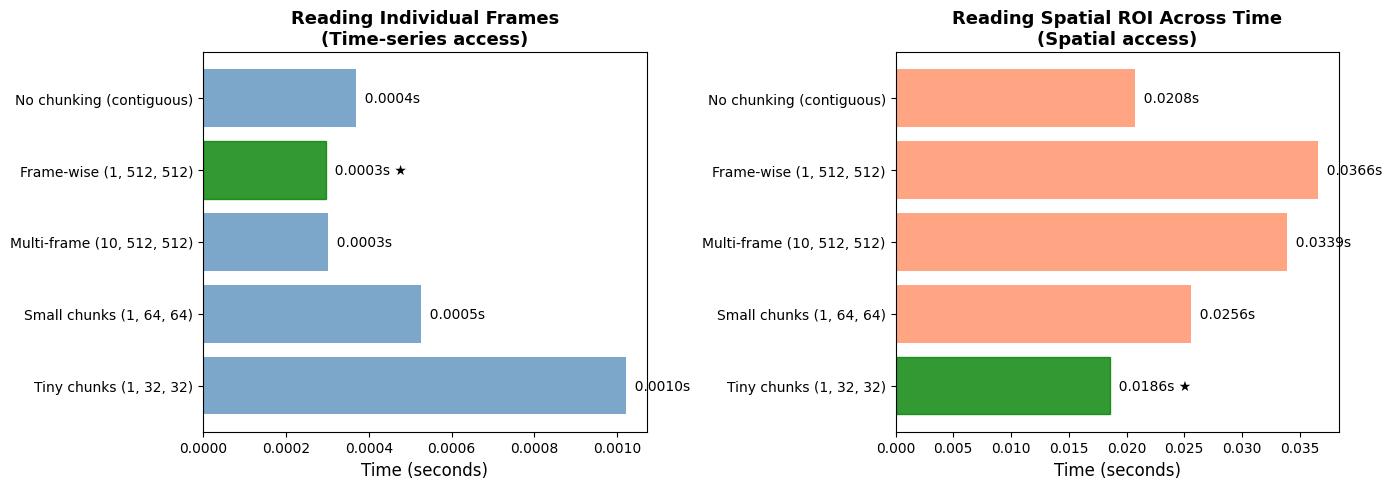


★ = Best performance for this access pattern


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Sort by performance
configs = list(chunk_files.keys())
frame_times = [frame_read_times[c] for c in configs]
roi_times = [roi_read_times[c] for c in configs]

# Plot 1: Frame reading
bars1 = ax1.barh(configs, frame_times, color='steelblue', alpha=0.7)
ax1.set_xlabel('Time (seconds)', fontsize=12)
ax1.set_title('Reading Individual Frames\n(Time-series access)', fontsize=13, fontweight='bold')
ax1.invert_yaxis()

# Highlight best
best_idx_frame = np.argmin(frame_times)
bars1[best_idx_frame].set_color('green')
bars1[best_idx_frame].set_alpha(0.8)

# Add time labels
for i, (bar, time_val) in enumerate(zip(bars1, frame_times)):
    width = bar.get_width()
    label = f'{time_val:.4f}s'
    if i == best_idx_frame:
        label += ' ★'
    ax1.text(width, bar.get_y() + bar.get_height()/2., 
             f'  {label}', va='center', fontsize=10)

# Plot 2: ROI reading
bars2 = ax2.barh(configs, roi_times, color='coral', alpha=0.7)
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_title('Reading Spatial ROI Across Time\n(Spatial access)', fontsize=13, fontweight='bold')
ax2.invert_yaxis()

# Highlight best
best_idx_roi = np.argmin(roi_times)
bars2[best_idx_roi].set_color('green')
bars2[best_idx_roi].set_alpha(0.8)

# Add time labels
for i, (bar, time_val) in enumerate(zip(bars2, roi_times)):
    width = bar.get_width()
    label = f'{time_val:.4f}s'
    if i == best_idx_roi:
        label += ' ★'
    ax2.text(width, bar.get_y() + bar.get_height()/2., 
             f'  {label}', va='center', fontsize=10)

plt.tight_layout()
save_fig(fig, 'hdfchunking', CHAPTER, basedir=IMAGE_DIR)

plt.show()

print("\n★ = Best performance for this access pattern")

### Chunking Best Practices Summary

**The Surprising Truth**: For simple sequential access patterns, **no chunking (contiguous storage) is often fastest**!

**When Chunking Actually Helps:**

1. **Compression** (requires chunking):
   - Can reduce file size 2-10x
   - Worth the read overhead for storage-limited situations
   
2. **Parallel writes**:
   - Multiple processes can write different chunks simultaneously
   
3. **Sparse random access**:
   - Only access small portions of large dataset
   - Chunks let you avoid reading unnecessary data

4. **Resizable datasets**:
   - Can grow datasets along chunked dimensions

**When to Skip Chunking:**

1. **Sequential reads** of full frames/slices
2. **Small files** that fit in memory/cache
3. **When I/O speed is critical** and compression isn't needed

**If You Must Chunk:**

1. **Align with access pattern**: 
   - Reading full frames? Use `(1, height, width)`
   - Random pixel access? Use `(many, small_h, small_w)`

2. **Target 10 KB - 1 MB per chunk**:
   - Too small: Metadata overhead dominates
   - Too large: Wasted I/O for partial reads

3. **Rule of thumb for 3D data**:
   ```python
   # Target ~100-500 KB per chunk
   target_bytes = 100_000
   bytes_per_element = 8  # float64
   
   # For frame-by-frame access:
   chunk_size = (1, height, width)
   
   # For random access:
   chunk_size = (many_frames, small_height, small_width)
   # where many_frames * small_height * small_width * 8 ≈ target_bytes
   ```

4. **Compression options**:
   - `'gzip'`: Best compression, slowest (levels 1-9)
   - `'lzf'`: Fast, moderate compression
   - None: Fastest, largest files

5. **Test your actual workflow**:
   - These examples show chunking overhead
   - Your data patterns may differ
   - Always profile with real data!

### Cleanup Chunk Test Files

In [15]:
# Clean up chunk test files
for filename in chunk_files.values():
    if os.path.exists(filename):
        os.remove(filename)


print("✓ Chunk test files cleaned up")

✓ Chunk test files cleaned up


## Cleanup

Remove the temporary files created during this demonstration.

In [16]:
import os

# Clean up temporary files
for filename in [subject_first_file, timepoint_first_file, flat_file]:
    if os.path.exists(filename):
        os.remove(filename)
        print(f"Removed: {filename}")

print("\n✓ Cleanup complete!")

Removed: /var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/tmppstbhhmg_subject_first.h5
Removed: /var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/tmpdiez1luh_timepoint_first.h5
Removed: /var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/tmpru_ps2ua_flat.h5

✓ Cleanup complete!
